In [1]:
import numpy as np
import pandas as pd 
from matplotlib import pyplot as plt

In [3]:
df=pd.read_csv('clean.csv')
df

,Unnamed: 0,Date,Pond_ID,Pond_Type,Target_Species,Season,Water_Temp_C,Weather_Condition,Rainfall_mm,pH_Level,...,High_Ammonia,High_Temp,Mortality_Rate,Weight_Gain_g,Feed_Efficiency,Total_Cost_NPR,Profit_Margin_Pct,Oxygen_3day_avg,Risk_Score,Risk_Level
0,0,2025-01-01,GrowOut-A,Farming,Pangasius,Winter,17.0,Cloudy,0.0,7.9,...,1,0,0.000000,0.0,0.000000,965,0.000000,8.500000,1,Medium
1,1,2025-01-02,GrowOut-A,Farming,Pangasius,Winter,15.7,Sunny,0.0,6.6,...,1,0,0.100010,0.2,0.047619,955,-0.477465,8.700000,1,Medium
2,2,2025-01-03,GrowOut-A,Farming,Pangasius,Winter,15.5,Sunny,0.0,7.4,...,1,0,0.300120,0.4,0.080000,1004,-0.166235,8.566667,1,Medium
3,3,2025-01-04,GrowOut-A,Farming,Pangasius,Winter,15.5,Cloudy,0.0,6.7,...,1,0,0.100050,0.3,0.056604,1036,-0.304161,8.433333,1,Medium
4,4,2025-01-05,GrowOut-A,Farming,Pangasius,Winter,19.2,Sunny,0.0,7.1,...,1,0,0.100060,0.3,0.062500,1006,-0.312096,8.133333,1,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
360,360,2025-12-27,Nursery,Nursery,Rohu,Winter,17.9,Sunny,0.0,7.7,...,1,0,0.000000,0.2,0.016260,1815,0.784190,8.266667,1,Medium
361,361,2025-12-28,Nursery,Nursery,Rohu,Winter,18.2,Cloudy,0.0,7.6,...,1,0,0.000000,0.1,0.009709,1572,0.218699,8.466667,1,Medium
362,362,2025-12-29,Nursery,Nursery,Rohu,Winter,14.8,Sunny,0.0,7.4,...,1,0,0.040111,0.1,0.009434,1589,0.194938,8.433333,1,Medium
363,363,2025-12-30,Nursery,Nursery,Rohu,Winter,15.6,Cloudy,0.0,7.6,...,1,0,0.020056,0.2,0.016393,1824,0.768278,8.866667,1,Medium


### Changing categories data into numeric 

In [4]:
df1=df.copy()

In [6]:
df1=pd.get_dummies(['Pond_ID', 'Pond_Type','Target_Species', 'Season','Weather_Condition','Risk_Level'])
df1

,Pond_ID,Pond_Type,Risk_Level,Season,Target_Species,Weather_Condition
0,True,False,False,False,False,False
1,False,True,False,False,False,False
2,False,False,False,False,True,False
3,False,False,False,True,False,False
4,False,False,False,False,False,True
5,False,False,True,False,False,False


In [ ]:
a=np.random.randint(15,25,10)


np.float64(18.97)

In [11]:
per=np.percentile(a,100)

per


np.float64(24.0)

In [12]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor

# =========================
# 1. LOAD DATA
# =========================
df = pd.read_csv("clean.csv")

# =========================
# 2. HANDLE DATE COLUMN
# =========================
df['Date'] = pd.to_datetime(df['Date'])

df['year'] = df['Date'].dt.year
df['month'] = df['Date'].dt.month
df['day'] = df['Date'].dt.day

df.drop('Date', axis=1, inplace=True)

# =========================
# 3. SPLIT FEATURES & TARGETS
# =========================
X = df.drop(['Risk_Score', 'Mortality_Rate', 'Risk_Level'], axis=1)
y = df[['Risk_Score', 'Mortality_Rate']]

# =========================
# 4. FIX OBJECT (STRING) COLUMNS
# =========================
X = pd.get_dummies(X)

# =========================
# 5. TRAIN TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================
# 6. TRAIN MODEL (XGBOOST)
# =========================
model = XGBRegressor(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)

model.fit(X_train, y_train)

# =========================
# 7. PREDICTION
# =========================
pred = model.predict(X_test)

risk_score_pred = pred[:, 0]
mortality_pred = pred[:, 1]

# =========================
# 8. EVALUATION
# =========================
print("Risk Score MSE:", mean_squared_error(y_test['Risk_Score'], risk_score_pred))
print("Mortality MSE:", mean_squared_error(y_test['Mortality_Rate'], mortality_pred))

# =========================
# 9. RISK LEVEL (DERIVED)
# =========================
def get_risk_level(score):
    if score < 30:
        return "Low"
    elif score < 70:
        return "Medium"
    else:
        return "High"

risk_level_pred = [get_risk_level(s) for s in risk_score_pred]

# =========================
# 10. FINAL OUTPUT
# =========================
results = pd.DataFrame({
    "Pred_Risk_Score": risk_score_pred,
    "Pred_Mortality_Rate": mortality_pred,
    "Pred_Risk_Level": risk_level_pred
})

print(results.head())

Risk Score MSE: 2.743716365216642e-09
Mortality MSE: 6.736931829201197e-07
   Pred_Risk_Score  Pred_Mortality_Rate Pred_Risk_Level
0         1.000025             0.000060             Low
1         1.000025             0.000059             Low
2         1.000025             0.100350             Low
3         1.000025             0.050041             Low
4         1.000025             0.000059             Low


In [13]:
print(df['Risk_Score'].describe())
print(df['Mortality_Rate'].describe())

count    365.000000
mean       1.164384
std        0.371132
min        1.000000
25%        1.000000
50%        1.000000
75%        1.000000
max        2.000000
Name: Risk_Score, dtype: float64
count    365.000000
mean       0.096115
std        0.138091
min        0.000000
25%        0.000000
50%        0.040060
75%        0.125770
max        0.637267
Name: Mortality_Rate, dtype: float64


In [15]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor

# =========================
# 1. LOAD DATA
# =========================
df = pd.read_csv("clean.csv")

# =========================
# 2. DATE FEATURE ENGINEERING
# =========================
df['Date'] = pd.to_datetime(df['Date'])

df['year'] = df['Date'].dt.year
df['month'] = df['Date'].dt.month
df['day'] = df['Date'].dt.day

df.drop('Date', axis=1, inplace=True)

# =========================
# 3. FEATURES & TARGETS
# =========================
X = df.drop(['Risk_Score', 'Feed_Efficiency'], axis=1)
y = df[['Risk_Score', 'Feed_Efficiency']]

# =========================
# 4. ENCODE CATEGORICAL FEATURES
# =========================
X = pd.get_dummies(X)

# =========================
# 5. TRAIN TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================
# 6. MODEL
# =========================
model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

# =========================
# 7. PREDICTIONS
# =========================
pred = model.predict(X_test)

risk_pred = pred[:, 0]
feed_pred = pred[:, 1]

# =========================
# 8. EVALUATION
# =========================
print("===== RISK SCORE =====")
print("MSE:", mean_squared_error(y_test['Risk_Score'], risk_pred))
print("R2 :", r2_score(y_test['Risk_Score'], risk_pred))

print("\n===== FEED EFFICIENCY =====")
print("MSE:", mean_squared_error(y_test['Feed_Efficiency'], feed_pred))
print("R2 :", r2_score(y_test['Feed_Efficiency'], feed_pred))

# =========================
# 9. OUTPUT
# =========================
results = pd.DataFrame({
    "Pred_Risk_Score": risk_pred,
    "Pred_Feed_Efficiency": feed_pred
})

print(results.head(10))

===== RISK SCORE =====
MSE: 2.8227862269858406e-09
R2 : 1.0

===== FEED EFFICIENCY =====
MSE: 4.6926102890253464e-05
R2 : 0.9511057005856548
   Pred_Risk_Score  Pred_Feed_Efficiency
0         1.000019              0.094304
1         1.000019              0.076556
2         1.000019              0.064845
3         1.000019              0.007849
4         1.000019              0.038165
5         1.000019              0.078330
6         1.000019              0.073473
7         1.999864              0.059353
8         1.000019              0.072642
9         1.000019              0.067805


===== RISK SCORE =====
MSE: 2.8227862269858406e-09
R2 : 1.0

===== FEED EFFICIENCY =====
MSE: 4.6926102890253464e-05
R2 : 0.9511057005856548
   Pred_Risk_Score  Pred_Feed_Efficiency
0         1.000019              0.094304
1         1.000019              0.076556
2         1.000019              0.064845
3         1.000019              0.007849
4         1.000019              0.038165

Initial Shape: (365, 39)
   Unnamed: 0        Date    Pond_ID Pond_Type Target_Species  Season  \
0           0  2025-01-01  GrowOut-A   Farming      Pangasius  Winter   
1           1  2025-01-02  GrowOut-A   Farming      Pangasius  Winter   
2           2  2025-01-03  GrowOut-A   Farming      Pangasius  Winter   
3           3  2025-01-04  GrowOut-A   Farming      Pangasius  Winter   
4           4  2025-01-05  GrowOut-A   Farming      Pangasius  Winter   

   Water_Temp_C Weather_Condition  Rainfall_mm  pH_Level  ...  High_Ammonia  \
0          17.0            Cloudy          0.0       7.9  ...             1   
1          15.7             Sunny          0.0       6.6  ...             1   
2          15.5             Sunny          0.0       7.4  ...             1   
3          15.5            Cloudy          0.0       6.7  ...             1   
4          19.2             Sunny          0.0       7.1  ...             1   

   High_Temp  Mortality_Rate  Weight_Gain_g  Feed_Efficiency 

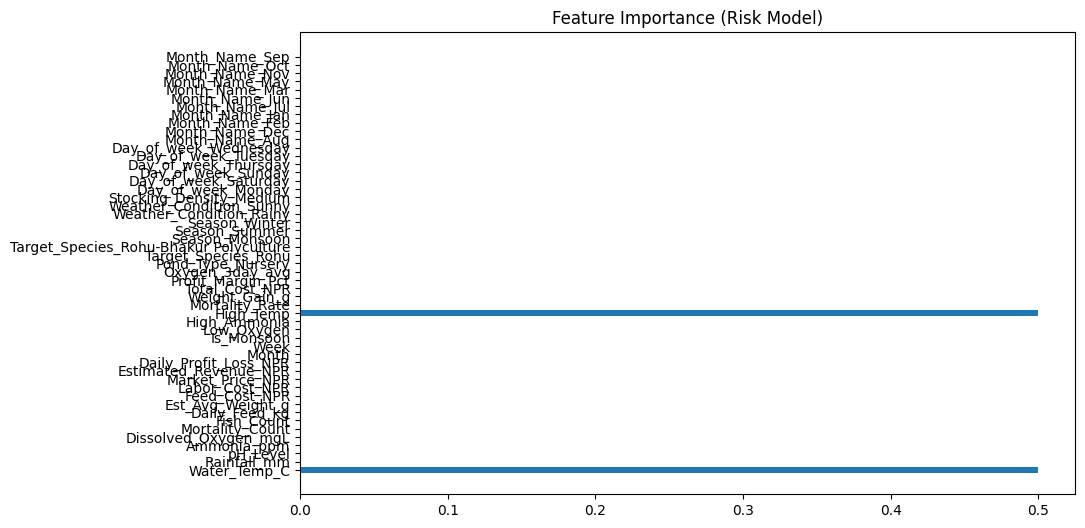


Models saved successfully!

===== SAMPLE PREDICTION =====
Predicted Risk Score: 1.0
Predicted Feed Efficiency: 0.05387267466066709


In [17]:
# ================================
# 1. IMPORT LIBRARIES
# ================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import joblib

# ================================
# 2. LOAD DATA
# ================================
df = pd.read_csv("clean.csv")

print("Initial Shape:", df.shape)
print(df.head())

# ================================
# 3. CLEAN DATA
# ================================

# Drop unnecessary columns
df = df.drop(columns=["Unnamed: 0", "Date", "Pond_ID"], errors="ignore")

# Drop Risk_Level to avoid leakage
df = df.drop(columns=["Risk_Level"], errors="ignore")

# Convert categorical → numeric
df = pd.get_dummies(df, drop_first=True)

# Fill missing values
df = df.fillna(df.mean())

print("\nCleaned Shape:", df.shape)

# ================================
# 4. DEFINE FEATURES & TARGETS
# (SAME INPUT FEATURES FOR BOTH MODELS)
# ================================

X = df.drop(columns=["Risk_Score", "Feed_Efficiency"])
y_risk = df["Risk_Score"]
y_feed = df["Feed_Efficiency"]

# ================================
# 5. TRAIN-TEST SPLIT
# ================================

X_train, X_test, y_risk_train, y_risk_test = train_test_split(
    X, y_risk, test_size=0.2, random_state=42
)

_, _, y_feed_train, y_feed_test = train_test_split(
    X, y_feed, test_size=0.2, random_state=42
)

# ================================
# 6. SCALING
# ================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ================================
# 7. TRAIN MODELS
# ================================

risk_model = RandomForestRegressor(n_estimators=100, random_state=42)
feed_model = RandomForestRegressor(n_estimators=100, random_state=42)

risk_model.fit(X_train_scaled, y_risk_train)
feed_model.fit(X_train_scaled, y_feed_train)

# ================================
# 8. PREDICTIONS
# ================================

risk_pred = risk_model.predict(X_test_scaled)
feed_pred = feed_model.predict(X_test_scaled)

# ================================
# 9. EVALUATION
# ================================

print("\n===== MODEL PERFORMANCE =====")

print("\n--- Risk Score Model ---")
print("MAE:", mean_absolute_error(y_risk_test, risk_pred))
print("R2 Score:", r2_score(y_risk_test, risk_pred))

print("\n--- Feed Efficiency Model ---")
print("MAE:", mean_absolute_error(y_feed_test, feed_pred))
print("R2 Score:", r2_score(y_feed_test, feed_pred))

# ================================
# 10. FEATURE IMPORTANCE
# ================================

importances = risk_model.feature_importances_
features = X.columns

plt.figure(figsize=(10, 6))
plt.barh(features, importances)
plt.title("Feature Importance (Risk Model)")
plt.show()

# ================================
# 11. SAVE MODELS
# ================================

joblib.dump(risk_model, "risk_model.pkl")
joblib.dump(feed_model, "feed_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("\nModels saved successfully!")

# ================================
# 12. SAMPLE PREDICTION (NO ERROR)
# ================================

sample = X.iloc[0:1]

sample_scaled = scaler.transform(sample)

predicted_risk = risk_model.predict(sample_scaled)
predicted_feed = feed_model.predict(sample_scaled)

print("\n===== SAMPLE PREDICTION =====")
print("Predicted Risk Score:", predicted_risk[0])
print("Predicted Feed Efficiency:", predicted_feed[0])

In [18]:
import pandas as pd
import joblib

# ================================
# 1. LOAD SAVED MODELS
# ================================
risk_model = joblib.load("risk_model.pkl")
feed_model = joblib.load("feed_model.pkl")
scaler = joblib.load("scaler.pkl")

# ================================
# 2. DEFINE INPUT FEATURES
# (MUST MATCH TRAINING FEATURES)
# ================================

# Example: adjust based on your dataset columns
input_data = {
    "Temperature": float(input("Enter Temperature: ")),
    "pH": float(input("Enter pH: ")),
    "Dissolved_Oxygen": float(input("Enter Oxygen Level: ")),
    "Ammonia": float(input("Enter Ammonia Level: ")),
    "Nitrite": float(input("Enter Nitrite Level: ")),
    "Stocking_Density": float(input("Enter Stocking Density: ")),
    "Feed_Quantity": float(input("Enter Feed Quantity: "))
}

# ================================
# 3. CONVERT TO DATAFRAME
# ================================
input_df = pd.DataFrame([input_data])

# ================================
# 4. HANDLE CATEGORICAL COLUMNS
# ================================
# IMPORTANT: match training columns

# Load training columns (save this once during training if needed)
# Example:
# joblib.dump(X.columns, "columns.pkl")

columns = joblib.load("columns.pkl")

# Align input with training columns
input_df = input_df.reindex(columns=columns, fill_value=0)

# ================================
# 5. SCALE INPUT
# ================================
input_scaled = scaler.transform(input_df)

# ================================
# 6. PREDICT
# ================================
risk_pred = risk_model.predict(input_scaled)
feed_pred = feed_model.predict(input_scaled)

# ================================
# 7. OUTPUT
# ================================
print("\n===== PREDICTION RESULT =====")
print("Predicted Risk Score:", risk_pred[0])
print("Predicted Feed Efficiency:", feed_pred[0])

FileNotFoundError: [Errno 2] No such file or directory: 'columns.pkl'

In [1]:
# ================================
# TRAINING CODE
# ================================

import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler

# 1. LOAD DATA
df = pd.read_csv("clean.csv")

# 2. CLEAN DATA
df = df.drop(columns=["Unnamed: 0", "Date", "Pond_ID"], errors="ignore")
df = df.drop(columns=["Risk_Level"], errors="ignore")

df = pd.get_dummies(df, drop_first=True)
df = df.fillna(df.mean())

# 3. FEATURES & TARGETS
X = df.drop(columns=["Risk_Score", "Feed_Efficiency"])
y_risk = df["Risk_Score"]
y_feed = df["Feed_Efficiency"]

# 🔥 SAVE COLUMNS (IMPORTANT)
joblib.dump(X.columns, "columns.pkl")

# 4. SPLIT
X_train, X_test, y_risk_train, y_risk_test = train_test_split(
    X, y_risk, test_size=0.2, random_state=42
)

_, _, y_feed_train, y_feed_test = train_test_split(
    X, y_feed, test_size=0.2, random_state=42
)

# 5. SCALING
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# 6. MODELS
risk_model = RandomForestRegressor(n_estimators=100, random_state=42)
feed_model = RandomForestRegressor(n_estimators=100, random_state=42)

risk_model.fit(X_train_scaled, y_risk_train)
feed_model.fit(X_train_scaled, y_feed_train)

# 7. SAVE EVERYTHING
joblib.dump(risk_model, "risk_model.pkl")
joblib.dump(feed_model, "feed_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("✅ Training complete & models saved!")

✅ Training complete & models saved!


In [5]:
import pandas as pd
import joblib

# Load models
risk_model = joblib.load("risk_model.pkl")
feed_model = joblib.load("feed_model.pkl")
scaler = joblib.load("scaler.pkl")
columns = joblib.load("columns.pkl")

# ================================
# USER INPUT (ONLY IMPORTANT ONES)
# ================================
input_data = {
    "Water_Temp_C": float(input("Water Temperature (°C): ")),
    "Rainfall_mm": float(input("Rainfall (mm): ")),
    "pH_Level": float(input("pH Level: ")),
    "Ammonia_ppm": float(input("Ammonia (ppm): ")),
    "Dissolved_Oxygen_mgL": float(input("Dissolved Oxygen (mg/L): ")),
    "Fish_Count": float(input("Fish Count: ")),
    "Daily_Feed_kg": float(input("Daily Feed (kg): ")),
    "Est_Avg_Weight_g": float(input("Avg Fish Weight (g): "))
}

# Categorical inputs
season = input("Season (Summer/Winter/Monsoon): ")
species = input("Species (Rohu / Rohu-Bhakur Polyculture): ")

# ================================
# CREATE FULL INPUT
# ================================
input_df = pd.DataFrame([input_data])

# Fill all missing columns with 0
for col in columns:
    if col not in input_df.columns:
        input_df[col] = 0

# Handle categorical columns
if f"Season_{season}" in input_df.columns:
    input_df[f"Season_{season}"] = 1

if f"Target_Species_{species}" in input_df.columns:
    input_df[f"Target_Species_{species}"] = 1

# Final column order
input_df = input_df[columns]

# ================================
# SCALE & PREDICT
# ================================
input_scaled = scaler.transform(input_df)

risk_pred = risk_model.predict(input_scaled)
feed_pred = feed_model.predict(input_scaled)

# ================================
# OUTPUT
# ================================
print("\n===== RESULT =====")
print(f"Predicted Risk Score: {risk_pred[0]:.4f}")
print(f"Predicted Feed Efficiency: {feed_pred[0]:.4f}")


===== RESULT =====
Predicted Risk Score: 1.5000
Predicted Feed Efficiency: 0.0396


In [4]:
df.columns


Index(['Water_Temp_C', 'Rainfall_mm', 'pH_Level', 'Ammonia_ppm',
       'Dissolved_Oxygen_mgL', 'Mortality_Count', 'Fish_Count',
       'Daily_Feed_kg', 'Est_Avg_Weight_g', 'Feed_Cost_NPR', 'Labor_Cost_NPR',
       'Market_Price_NPR', 'Estimated_Revenue_NPR', 'Daily_Profit_Loss_NPR',
       'Month', 'Week', 'Is_Monsoon', 'Low_Oxygen', 'High_Ammonia',
       'High_Temp', 'Mortality_Rate', 'Weight_Gain_g', 'Feed_Efficiency',
       'Total_Cost_NPR', 'Profit_Margin_Pct', 'Oxygen_3day_avg', 'Risk_Score',
       'Pond_Type_Nursery', 'Target_Species_Rohu',
       'Target_Species_Rohu-Bhakur Polyculture', 'Season_Monsoon',
       'Season_Summer', 'Season_Winter', 'Weather_Condition_Rainy',
       'Weather_Condition_Sunny', 'Stocking_Density_Medium',
       'Day_of_week_Monday', 'Day_of_week_Saturday', 'Day_of_week_Sunday',
       'Day_of_week_Thursday', 'Day_of_week_Tuesday', 'Day_of_week_Wednesday',
       'Month_Name_Aug', 'Month_Name_Dec', 'Month_Name_Feb', 'Month_Name_Jan',
       'Month_